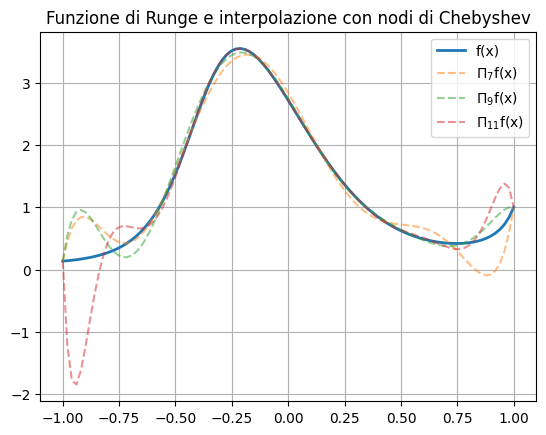

In [18]:
#tde 11/07/2022
#es.2 interpolazione
import numpy as np
import matplotlib.pyplot as plt
from numpy import interp

#intervallo e funzione
a=-1
b=1
f=lambda x: np.exp(np.cos(np.pi*x))/(np.exp(-x)+np.sin(np.pi*x))
x_grid=np.linspace(a, b, 100)
n_list=[5, 10, 20]
num_intervalli = [7, 9, 11]

err=[]

plt.figure()
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi di Chebyshev")
plt.grid()

# Costruzione delle interpolanti e rappresentazione (n intervalli -> n+1 nodi)
for n in num_intervalli: 
    x_nodi=np.linspace(a, b, n+1)
    y_nodi=f(x_nodi)
    p=np.polyfit(x_nodi, y_nodi, n)
    y=np.polyval(p, x_grid)
    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)
    err.append(np.linalg.norm(f(x_grid)-y))


plt.legend()
plt.show()



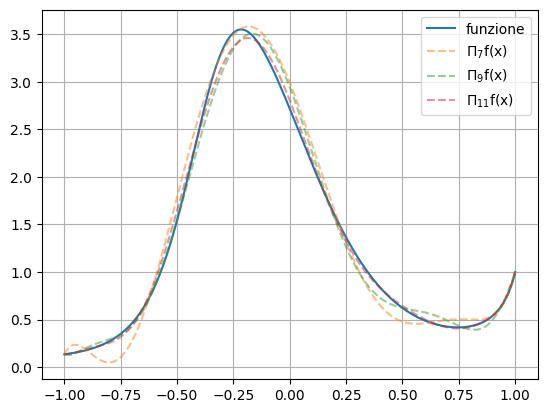

In [19]:
#b) punto precedente con nodi di CGL
def nodi_Chebyshev(a, b, n):
  """
  Calcolo degli n+1 nodi di Chebyshev sull'intervallo [a,b]
  Input:
  a: estremo sinistro dell'intervallo
  b: estremo destro dell'intervallo
  n: numero di intervalli (n+1 nodi) pari al grado del polinomio approssimante/interpolante
  Output:
  x: nodi di Chebyshev
  """
  x_cgl=[]
  x_old=-np.cos((np.pi*i)/n) #è x con cappuccio
  
  for i in range(n):
    x_new=(a+b)*0.5 + (b-a)*0.5*x_old #nodi di chebichev sul generico intervallo
    x_cgl.append(x_new)

  return x_cgl

#oppure
def nodi_Chebyshev(a, b, n):
  i=np.arange(n+1) #i da 0 a n -> con arange devo fare n+1 per INCLUDERE n, dal momento che arange esclude l'ultimo estremo
  x_old=-np.cos((np.pi*i)/n)
  x_new=(a+b)*0.5 + (b-a)*0.5*x_old

  return x_new

#intervallo e funzione
a=-1
b=1
f=lambda x: np.exp(np.cos(np.pi*x))/(np.exp(-x)+np.sin(np.pi*x))
n_list=[5, 10, 20]
x_grid=np.linspace(a, b, 1000)
plt.figure()
plt.plot(x_grid, f(x_grid), label='funzione')
plt.grid()

err=[]

# Costruzione delle interpolanti e rappresentazione (n intervalli -> n+1 nodi) con nodi cgl
for n in num_intervalli: 
    x_nodi=nodi_Chebyshev(a, b, n)
    y_nodi=f(x_nodi)

    p=np.polyfit(x_nodi, y_nodi, n)
    y=np.polyval(p, x_grid)
    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)
    err.append(np.linalg.norm(f(x_grid)-y))


plt.legend()
plt.show()

In [ ]:
#con l'introduzion dei nodi GDL emerge chiaramente che rispetto ai nodi equispaziati
#impiegati in precedenza questi riescono a garantire un fenomeno di oscillazione
#agli estremi dell'intervallo molto più contenuto -> migliore convergenza degli interpolanti
#alla funzione originaria. Ciò è legato anche all'andamento dell'errore commesso interpolando
#la funzione con i polinomi caratteristici di Lagrange con nodi equispaziati o nodi cgl, 
#come emerge dal diverso andamento della costante di Lebesgue per i due casi.

In [ ]:
#c) discutere le proprietà di convergenza dell'interpolante Lagrangiana (teoria)